In [1]:
import sys 
import os

In [2]:
current_dir = os.path.dirname(os.path.abspath('.'))
project_root = os.path.abspath(os.path.join(current_dir, ".."))
sys.path.insert(0, project_root)

In [3]:
import pandas as pd
import yaml
import pickle
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay
import shap

In [4]:
yaml_path = rf"..\config\config.yaml"
with open(yaml_path, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

In [5]:
yaml_path = rf"..\config\model.yaml"
with open(yaml_path, "r", encoding="utf-8") as f:
    config_model = yaml.safe_load(f)

# Params

# Read Train / val dataset

In [6]:
pipeline_name="Pipeline3"

In [7]:
X_train = pd.read_parquet(fr'..\data\feature_eng\X_train_feat_eng_{pipeline_name}.parquet')
y_train = pd.read_parquet(fr'..\data\feature_eng\y_train_feat_eng_{pipeline_name}.parquet')  

X_val = pd.read_parquet(fr'..\data\feature_eng\X_val_feat_eng_{pipeline_name}.parquet')
y_val = pd.read_parquet(fr'..\data\feature_eng\y_val_feat_eng_{pipeline_name}.parquet')

In [8]:
model_name = "LGBMClassifier_Pipeline3"

In [9]:
model_path = rf'..\models\single_model\pkl\{model_name}.pkl'
with open(model_path, "rb") as file:
        model = pickle.load(file)

c:\Users\gustavo\anaconda3\envs\explain\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.5.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\gustavo\anaconda3\envs\explain\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.5.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


# Drop columns

In [11]:
X_train.drop(
    columns=config_model['single_model']['cols_2_drop'], 
    inplace=True)

X_val.drop(
    columns=config_model['single_model']['cols_2_drop'], 
    inplace=True)


In [24]:
X_train.categorical_pipe__Pclass.unique()

array([ 1.61413602,  0.40055118, -0.81303367])

# Partial dependence plot

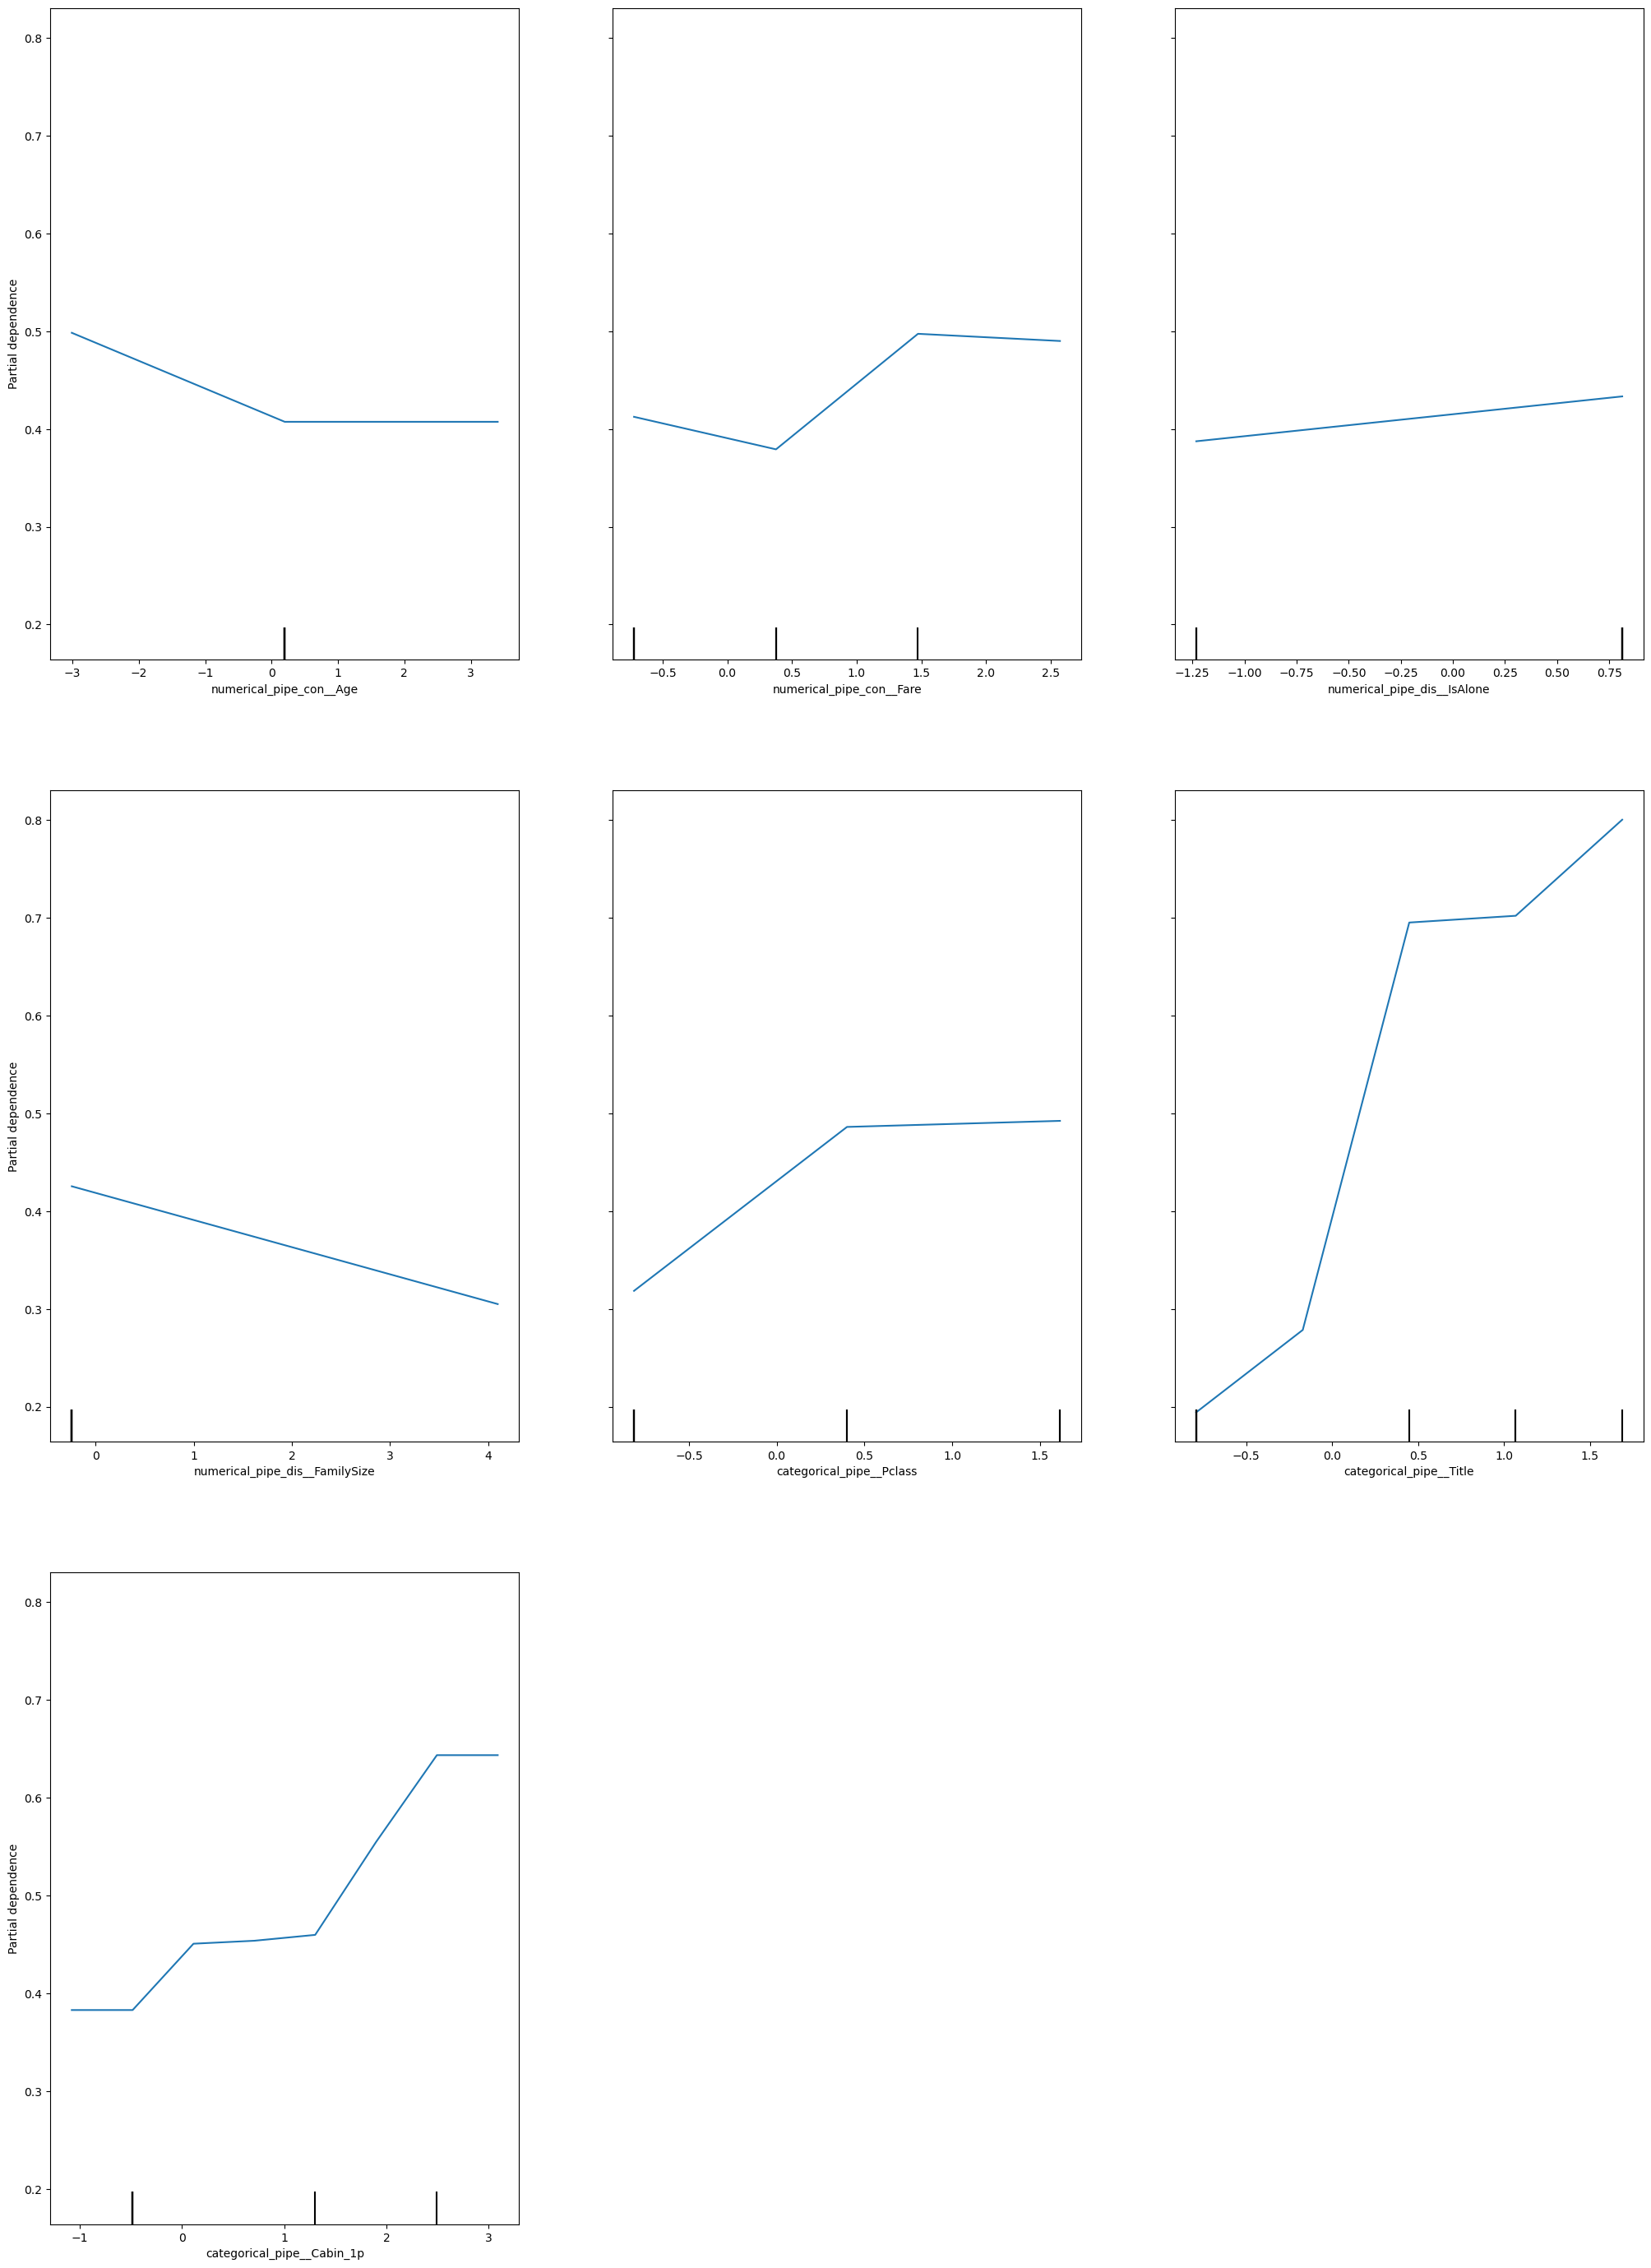

In [13]:
fig, ax = plt.subplots(figsize=(25, 35))
PartialDependenceDisplay.from_estimator(
        estimator=model,
        X=X_val,
        features = X_val.columns.tolist(),
        # categorical_features=X_val.columns[X_val.columns.str.contains('categorical_pipe')],
        random_state=23,
        ax=ax
    )

# Shap Values

In [14]:
X_val_proba = model.predict_proba(X_val)

In [15]:
explainer = shap.Explainer(model.predict_proba, X_train)

In [16]:
shap_values_train = explainer(X_train)
shap_values_val = explainer(X_val)

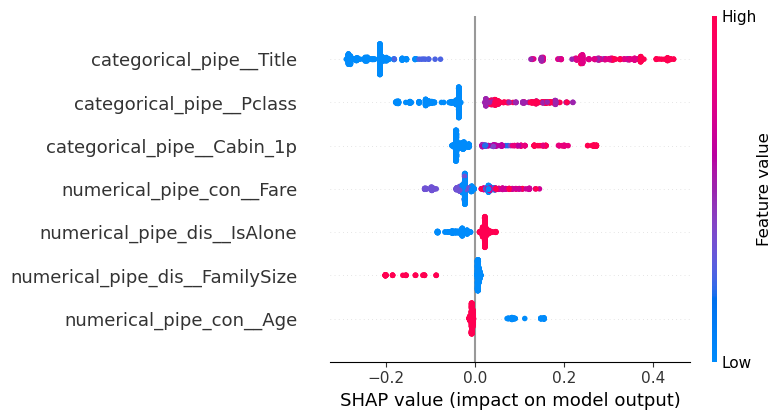

In [17]:
# Classe positiva (geralmente índice 1)
shap.summary_plot(
    shap_values_train.values[:, :, 1],
    X_train
)

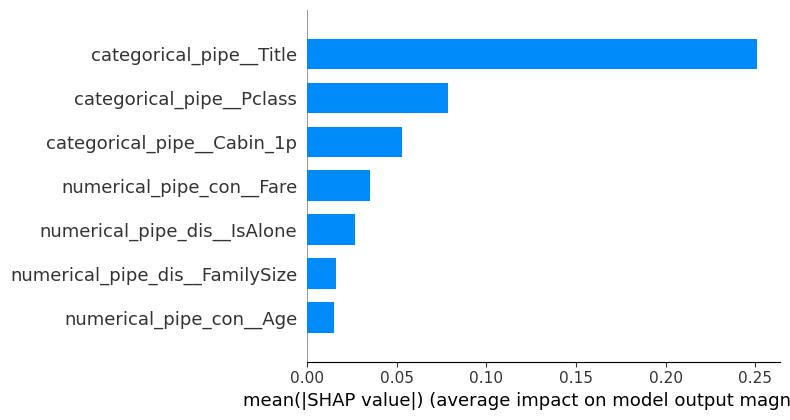

In [ ]:
shap.summary_plot(
    shap_values_train.values[:, :, 1],
    X_train,
    plot_type="bar"
)

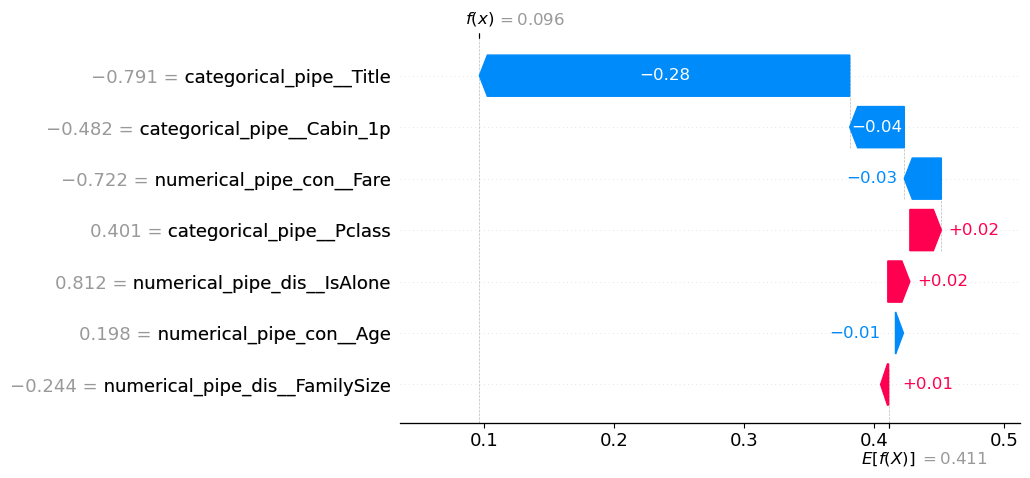

In [19]:
shap.plots.waterfall(shap_values_val[1,:,1])

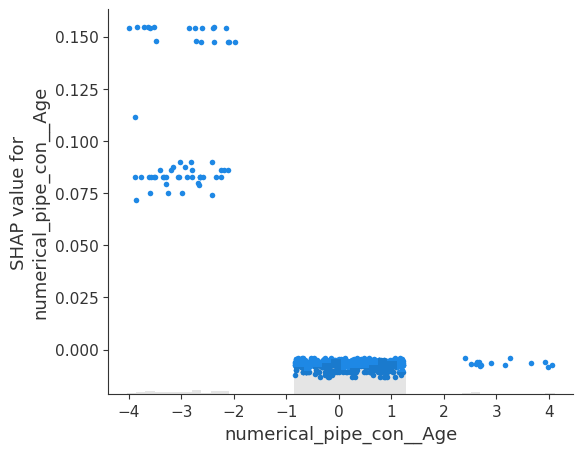

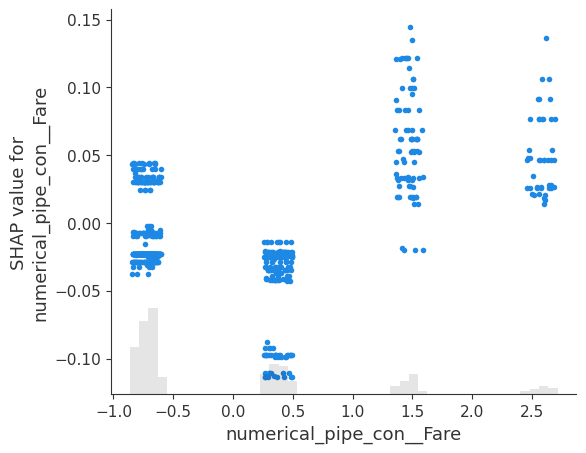

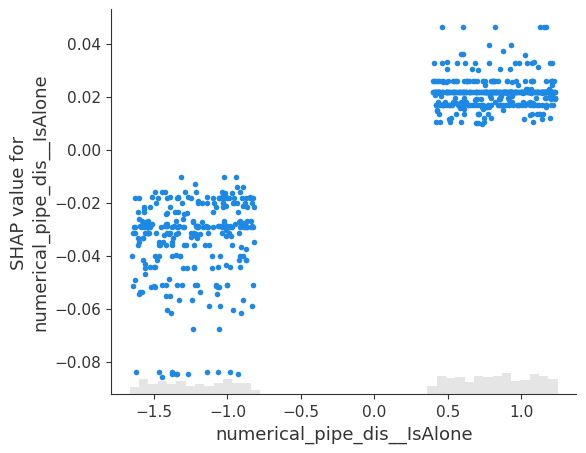

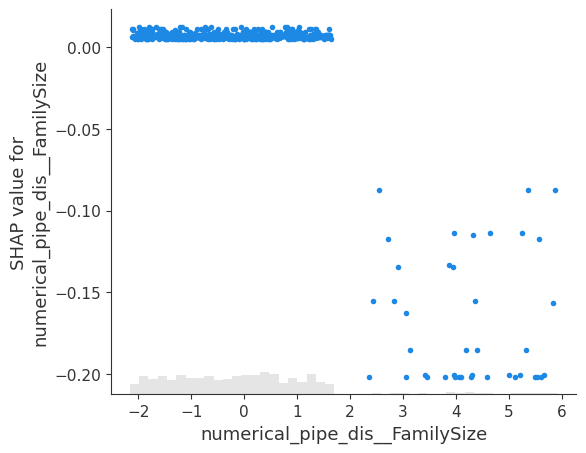

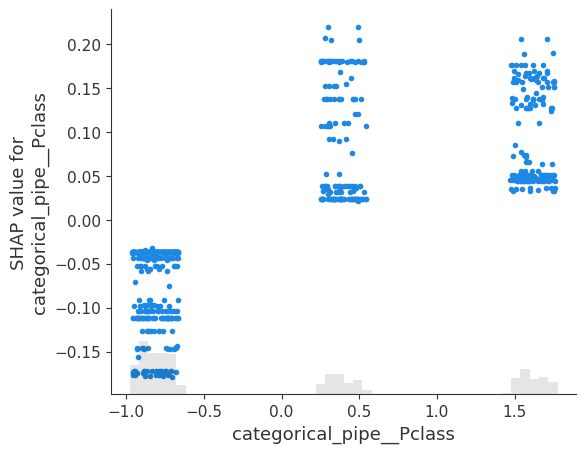

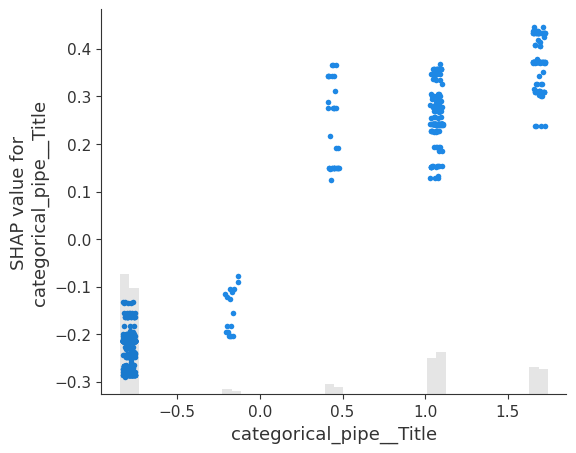

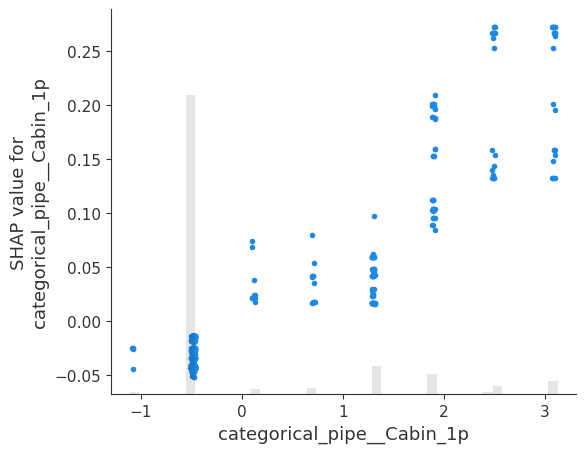

In [20]:
for col in X_val.columns:
    shap.plots.scatter(shap_values_train[:,col,1])

In [ ]:
X_train['numerical_pipe_dis__FamilySize'].unique()